In [12]:
import sys
import copy
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.svm import SVC

sys.path.insert(0, '..')
from src.model_pipeline import train_predict

import src.visuals as vs

%matplotlib inline

In [13]:
data = pd.read_csv(r'E:\CharityML-Donor-Prediction\CharityML-Donor-Prediction\data\processed\census_cleaned.csv')

income = data['income']
features_final = data.drop('income', axis=1)

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    features_final, income,
    test_size=0.2,
    random_state=42
)

In [15]:
clf_A = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
clf_B = AdaBoostClassifier(n_estimators=100, random_state=42)
clf_C = SVC(kernel='rbf', random_state=42)

In [16]:
samples_1   = int(len(X_train) * 0.01)   
samples_10  = int(len(X_train) * 0.10)   
samples_100 = len(X_train)               

In [17]:
accuracy_naive = 0.2478
fscore_naive   = 0.2917

In [18]:
results = {}

for clf, label in [
    (clf_A, 'Random Forest'),
    (clf_B, 'AdaBoost'),
    (clf_C, 'SVM'),
]:
    results[label] = []
    for size in [samples_1, samples_10, samples_100]:
        results[label].append(
            train_predict(copy.deepcopy(clf), size, X_train, y_train, X_test, y_test)
        )

RandomForestClassifier trained on 361 samples.
  Train time : 0.1768s  |  Pred time : 0.0417s
  Acc (train): 1.0000  |  Acc (test) : 0.8371
  F0.5(train): 1.0000  |  F0.5(test) : 0.6869

RandomForestClassifier trained on 3617 samples.
  Train time : 0.1877s  |  Pred time : 0.0407s
  Acc (train): 0.9931  |  Acc (test) : 0.8395
  F0.5(train): 0.9872  |  F0.5(test) : 0.6934

RandomForestClassifier trained on 36177 samples.
  Train time : 2.2526s  |  Pred time : 0.0741s
  Acc (train): 0.9721  |  Acc (test) : 0.8439
  F0.5(train): 0.9497  |  F0.5(test) : 0.7001

AdaBoostClassifier trained on 361 samples.
  Train time : 0.2622s  |  Pred time : 0.5727s
  Acc (train): 0.8947  |  Acc (test) : 0.8431
  F0.5(train): 0.8267  |  F0.5(test) : 0.7104

AdaBoostClassifier trained on 3617 samples.
  Train time : 0.6183s  |  Pred time : 0.3006s
  Acc (train): 0.8579  |  Acc (test) : 0.8489
  F0.5(train): 0.7271  |  F0.5(test) : 0.7283

AdaBoostClassifier trained on 36177 samples.
  Train time : 4.5420s  

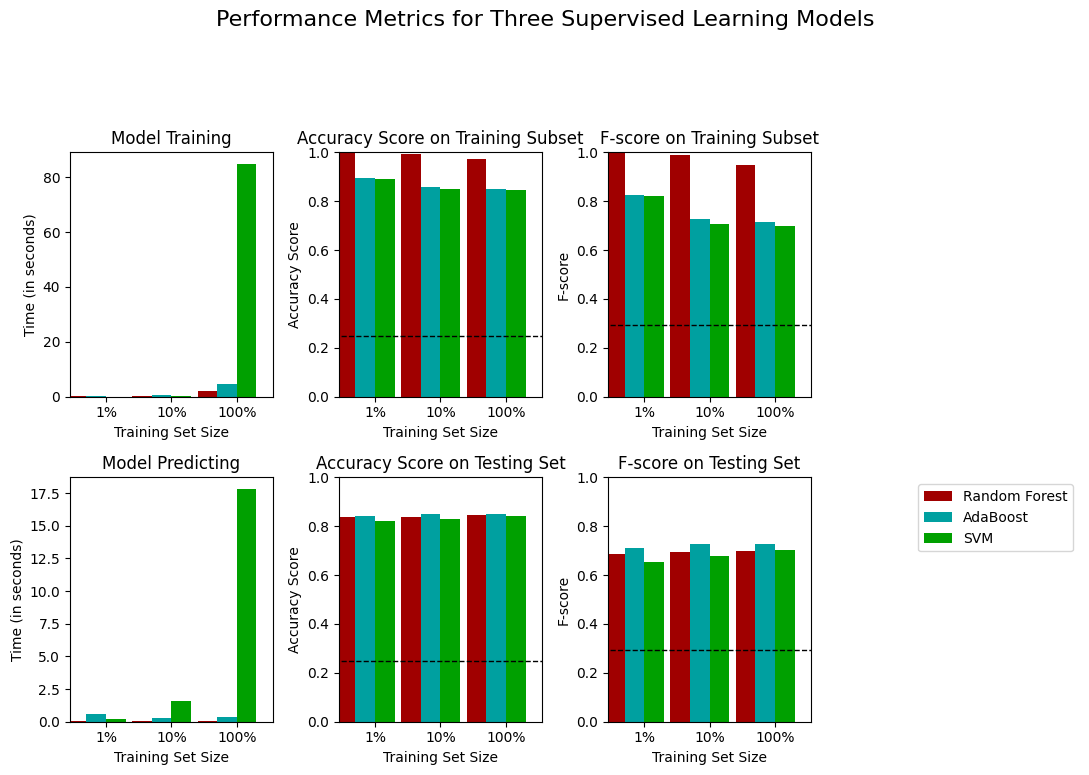

In [19]:
vs.evaluate(results, accuracy_naive, fscore_naive)

In [20]:
rows = []
for model_name, model_results in results.items():
    r = model_results[2] 
    rows.append({
        'Model'           : model_name,
        'Train Time (s)'  : round(r['train_time'], 4),
        'Pred Time (s)'   : round(r['pred_time'],  4),
        'Acc (Test)'      : round(r['acc_test'],   4),
        'F-0.5 (Test)'    : round(r['f_test'],     4),
    })

summary = pd.DataFrame(rows).set_index('Model')
summary

,Train Time (s),Pred Time (s),Acc (Test),F-0.5 (Test)
Model,,,,
Random Forest,2.2526,0.0741,0.8439,0.7001
AdaBoost,4.5420,0.3855,0.8519,0.7274
SVM,84.8418,17.8087,0.8413,0.7030
